# Week 1 — Data Preprocessing & Time-Series Decomposition

**Goal:** Turn the messy raw export into a clean, analysis-ready dataset, then
build a gap-free **daily** series per product category for forecasting and
anomaly detection to build on in later weeks.

**Raw data problems found and fixed here:**
- Inconsistent column name (`cddate`) and an empty trailing column
- Category names with mixed case, stray whitespace/tabs, underscores/hyphens,
  and outright typos (`Furnture`, `Beuaty`, `Electronis`, `Appearl`, ...)
- Multiple date formats mixed together (`DD-MM-YYYY`, `MM-DD-YYYY`, `DD-Mon-YY`)
- `promotion_flag` encoded inconsistently (`0/1`, `TRUE/FALSE`, `Yes/No`, `Y/N`)
- Missing values in the numeric columns and ~1.5% exact duplicate rows
- **Sentinel error codes** (`999999`) and **impossible negative values** in the
  numeric columns, which silently wreck any model fit on them if left in
- Gaps and duplicate dates within each category's daily series


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

RAW_PATH = Path('..') / 'data' / 'raw' / 'supply_chain_raw_data.csv'
CLEANED_OUT = Path('..') / 'data' / 'processed' / 'supply_chain_cleaned_data.csv'
DAILY_OUT = Path('..') / 'data' / 'processed' / 'supply_chain_daily.csv'

NUM_COLS = ['units_sold', 'inventory_level', 'unit_price', 'warehouse_dispatch_rate']

raw = pd.read_csv(RAW_PATH)
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (11165, 8)


,cddate,product_category,units_sold,inventory_level,unit_price,promotion_flag,warehouse_dispatch_rate,Unnamed: 7
0,20-Sep-22,Furnture,375.5,1158.3,73.29,0,338.2,NaN
1,30-08-2020,Beuaty\t,351.6,1056.9,165.31,0,367.4,NaN
2,10-May-20,Beauty,-339.2,1122.2,missing,0,341.8,NaN
3,07-10-2020,SPORTING GOODS,523.7,-,127.56,FALSE,523.5,NaN
4,05-08-2022,toys,397.5,568.7,239.06,FALSE,399.8,NaN


## 1. Fix column names and drop junk columns

In [2]:
df = raw.rename(columns={'cddate': 'date'})
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print(df.columns.tolist())
print('Nulls per column:\n', df.isna().sum())

['date', 'product_category', 'units_sold', 'inventory_level', 'unit_price', 'promotion_flag', 'warehouse_dispatch_rate']
Nulls per column:
 date                         0
product_category             0
units_sold                 391
inventory_level            287
unit_price                 238
promotion_flag               0
warehouse_dispatch_rate    260
dtype: int64


## 2. Normalize product categories

Strip whitespace/tabs, collapse separators, upper-case for matching, correct
known typos, then title-case the result so every row lands in one of the
11 canonical categories.

In [3]:
TYPO_MAP = {
    'APPEARL': 'APPAREL',
    'AUTO PARTS': 'AUTOMOTIVE PARTS',
    'BEUATY': 'BEAUTY',
    'ELECTRONIC': 'ELECTRONICS',
    'ELECTRONIS': 'ELECTRONICS',
    'FURNTURE': 'FURNITURE',
    'GROCERY': 'GROCERIES',
    'GROCERYS': 'GROCERIES',
    'OFFICESUPPLIES': 'OFFICE SUPPLIES',
    'PETSUPPLIES': 'PET SUPPLIES',
    'SPORT GOODS': 'SPORTING GOODS',
    'TOY': 'TOYS',
}

def normalize_category(raw_value):
    val = str(raw_value).strip().replace('\t', '')
    val = val.replace('_', ' ').replace('-', ' ')
    val = ' '.join(val.split())  # collapse repeated spaces
    key = val.upper()
    key = TYPO_MAP.get(key, key)
    return key.title()

df['product_category'] = df['product_category'].apply(normalize_category)
print('Categories after cleaning:', sorted(df['product_category'].unique()))
print('Count:', df['product_category'].nunique())

Categories after cleaning: ['Apparel', 'Automotive Parts', 'Beauty', 'Clothing', 'Electronics', 'Furniture', 'Groceries', 'Office Supplies', 'Pet Supplies', 'Sporting Goods', 'Toys']
Count: 11


## 3. Parse mixed date formats

The raw export mixes `DD-MM-YYYY`, `MM-DD-YYYY`, and `DD-Mon-YY` (e.g. `26-Jan-21`).
We try each format in turn and keep the first one that parses for a given row.

In [4]:
DATE_FORMATS = ['%d-%m-%Y', '%m-%d-%Y', '%d-%b-%y']

def parse_date(value):
    for fmt in DATE_FORMATS:
        try:
            return pd.to_datetime(value, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df['date'] = df['date'].apply(parse_date)
print('Unparseable dates:', df['date'].isna().sum())
print('Date range:', df['date'].min(), '->', df['date'].max())

Unparseable dates: 0
Date range: 2020-01-01 00:00:00 -> 2023-04-01 00:00:00


## 4. Normalize the promotion flag and numeric columns

In [5]:
TRUE_VALUES = {'1', 'TRUE', 'YES', 'Y'}

df['promotion_flag'] = (df['promotion_flag'].astype(str).str.strip().str.upper()
                         .isin(TRUE_VALUES))

for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[['promotion_flag'] + NUM_COLS].isna().sum())

promotion_flag               0
units_sold                 789
inventory_level            646
unit_price                 907
warehouse_dispatch_rate    382
dtype: int64


## 5. Remove sentinel error codes and impossible values

Every numeric column contains a `999999` sentinel (a system error code, not a
real reading) and a handful of negative values, which are physically
impossible for units sold, inventory, price, or dispatch rate. Both are
treated as missing rather than real data.

In [6]:
SENTINEL = 99999  # anything at/above this is a system error code, not real data

before_nulls = df[NUM_COLS].isna().sum().sum()
for col in NUM_COLS:
    invalid = (df[col] >= SENTINEL) | (df[col] < 0)
    df.loc[invalid, col] = np.nan
after_nulls = df[NUM_COLS].isna().sum().sum()
print(f'Numeric cells nulled out as sentinel/negative: {after_nulls - before_nulls}')
print(df[NUM_COLS].describe())

Numeric cells nulled out as sentinel/negative: 562
         units_sold  inventory_level    unit_price  warehouse_dispatch_rate
count  10201.000000     10225.000000  10203.000000             10745.000000
mean     369.799510       863.849428    143.299748               378.185016
std      150.852082       302.665645     60.763159               335.129571
min      102.200000       153.500000     43.190000                11.500000
25%      286.300000       640.100000     89.780000               275.900000
50%      348.900000       803.900000    156.200000               339.000000
75%      427.000000      1060.900000    196.660000               416.800000
max     3255.400000      1524.100000    250.370000              6787.000000


## 6. Drop duplicates and missing rows

Exact duplicate rows are removed outright. Rows still missing a required value
after cleaning (unparseable date, or a numeric field that never converted) are
dropped rather than guessed at, since imputing raw records risks hiding real
data-entry errors.

In [7]:
before = len(df)
df = df.drop_duplicates()
df = df.dropna(subset=['date'] + NUM_COLS)
df = df.sort_values(['product_category', 'date']).reset_index(drop=True)
print(f'Rows: {before} -> {len(df)} ({before - len(df)} removed)')
print('Remaining duplicate (category, date) pairs:',
      df.duplicated(subset=['product_category', 'date']).sum())

Rows: 11165 -> 8063 (3102 removed)
Remaining duplicate (category, date) pairs: 342


## 7. Save the cleaned (but still irregular) dataset

This keeps the original daily granularity and any duplicate/missing dates —
it's the raw truth, just with clean types and labels.

In [8]:
CLEANED_OUT.parent.mkdir(parents=True, exist_ok=True)
cleaned = df.copy()
cleaned['date'] = cleaned['date'].dt.strftime('%d-%m-%Y')
cleaned.to_csv(CLEANED_OUT, index=False)
print('Saved', len(cleaned), 'rows ->', CLEANED_OUT)
cleaned.head()

Saved 8063 rows -> ../data/processed/supply_chain_cleaned_data.csv


,date,product_category,units_sold,inventory_level,unit_price,promotion_flag,warehouse_dispatch_rate
0,01-01-2020,Apparel,453.9,719.0,168.09,False,426.4
1,02-01-2020,Apparel,445.1,716.9,171.46,False,69.9
2,03-01-2020,Apparel,483.4,711.2,167.15,False,463.2
3,04-01-2020,Apparel,600.6,712.1,172.11,True,557.1
4,05-01-2020,Apparel,407.2,1216.3,171.24,False,422.8


## 8. Build a gap-free daily series per category

For forecasting and anomaly detection we need one row per category per
calendar day. For each category we:
1. Average away any duplicate-date rows,
2. Reindex onto the full daily calendar between its first and last date,
3. Linearly interpolate the small number of missing days.

`Clothing` has the sparsest raw coverage, so a large share of its series ends
up interpolated — later notebooks flag this so its results are read with
appropriate caution.

In [9]:
def build_daily(frame):
    parts = []
    for cat, sub in frame.groupby('product_category'):
        sub = sub.groupby('date', as_index=True)[NUM_COLS + ['promotion_flag']].mean()
        full_index = pd.date_range(sub.index.min(), sub.index.max(), freq='D')
        n_missing = len(full_index) - len(sub)
        sub = sub.reindex(full_index)
        sub[NUM_COLS] = sub[NUM_COLS].interpolate(method='linear').ffill().bfill()
        sub['promotion_flag'] = sub['promotion_flag'].fillna(False).round().astype(bool)
        sub['product_category'] = cat
        sub['interpolated_pct'] = round(100 * n_missing / len(full_index), 1)
        sub = sub.reset_index().rename(columns={'index': 'date'})
        parts.append(sub)
    return pd.concat(parts, ignore_index=True)

daily = build_daily(df)
coverage = (daily.groupby('product_category')['interpolated_pct'].first()
                  .sort_values(ascending=False))
print('Share of each category that is interpolated:')
print(coverage)

Share of each category that is interpolated:
product_category
Clothing            86.9
Apparel             40.4
Automotive Parts    35.8
Beauty              32.7
Groceries           31.5
Furniture           31.4
Toys                30.0
Sporting Goods      29.4
Office Supplies     29.4
Pet Supplies        28.9
Electronics         28.2
Name: interpolated_pct, dtype: float64


In [10]:
DAILY_OUT.parent.mkdir(parents=True, exist_ok=True)
daily_out = daily.drop(columns=['interpolated_pct']).sort_values(['product_category', 'date'])
daily_out.to_csv(DAILY_OUT, index=False)
print('Saved', len(daily_out), 'rows ->', DAILY_OUT)
daily_out.head()

Saved 12200 rows -> ../data/processed/supply_chain_daily.csv


,date,units_sold,inventory_level,unit_price,warehouse_dispatch_rate,promotion_flag,product_category
0,2020-01-01,453.9,719.0,168.09,426.4,False,Apparel
1,2020-01-02,445.1,716.9,171.46,69.9,False,Apparel
2,2020-01-03,483.4,711.2,167.15,463.2,False,Apparel
3,2020-01-04,600.6,712.1,172.11,557.1,True,Apparel
4,2020-01-05,407.2,1216.3,171.24,422.8,False,Apparel


## 9. Decompose one category to sanity-check trend & seasonality

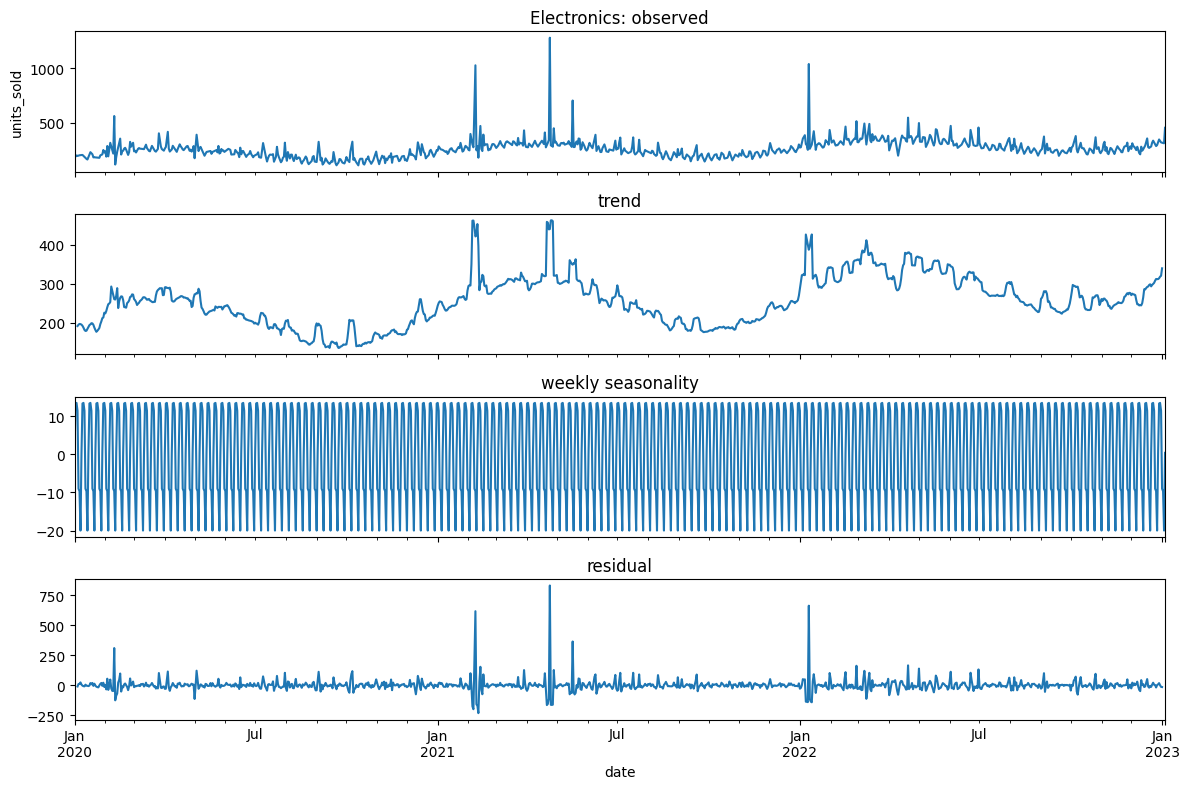

In [11]:
SAMPLE_CAT = 'Electronics'
sample = daily_out[daily_out['product_category'] == SAMPLE_CAT].set_index('date')['units_sold']
result = seasonal_decompose(sample, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
result.observed.plot(ax=axes[0], title=f'{SAMPLE_CAT}: observed'); axes[0].set_ylabel('units_sold')
result.trend.plot(ax=axes[1], title='trend'); axes[1].set_ylabel('')
result.seasonal.plot(ax=axes[2], title='weekly seasonality'); axes[2].set_ylabel('')
result.resid.plot(ax=axes[3], title='residual'); axes[3].set_ylabel('')
plt.tight_layout()
plt.show()

## 10. Summary

| Step | Outcome |
|---|---|
| Category typos/casing/whitespace | Normalized to 11 canonical categories |
| Mixed date formats | Parsed into a single `datetime` column |
| Inconsistent promo flag | Normalized to boolean |
| `999999` sentinels and negative values | Treated as missing, not as real data |
| Duplicate rows | Removed |
| Rows with unrecoverable missing data | Dropped |
| Per-category date gaps | Reindexed to a full daily calendar and interpolated |

Outputs written for the rest of the pipeline:
- `data/processed/supply_chain_cleaned_data.csv` — clean but irregular daily records
- `data/processed/supply_chain_daily.csv` — gap-free daily series used by Weeks 2-3
